In [1]:
import os
import pandas as pd
import numpy as np
import sys
import re
import logging
from Modules.Loader_wrangler import *
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
# Configure basic logging
logging.basicConfig(level=logging.INFO, force=True, format='%(levelname)s: %(message)s')

In [1]:
df2017 = loader(output_file_name="merged_df2017.pkl", chunksize=100000, sample_size=100000, survey_year=2017)
df2018 = loader(output_file_name="merged_df2018.pkl", chunksize=100000, sample_size=100000, survey_year=2018)
df2019 = loader(output_file_name="merged_df2019.pkl", chunksize=100000, sample_size=100000, survey_year=2019)
df2020 = loader(output_file_name="merged_df2020.pkl", chunksize=100000, sample_size=100000, survey_year=2020)
df2021 = loader(output_file_name="merged_df2021.pkl", chunksize=100000, sample_size=100000, survey_year=2021)

NameError: name 'loader' is not defined

In [3]:
nts2017 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2017.pkl")
nts2018 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2018.pkl")
nts2019 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2019.pkl")
nts2020 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2020.pkl")
nts2021 = pd.read_pickle("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/merged_df2021.pkl")

In [16]:
nts2017["IsTrip"] = 1
nts2018["IsTrip"] = 1
nts2019["IsTrip"] = 1
nts2020["IsTrip"] = 1
nts2021["IsTrip"] = 1

In [17]:
nts2017["JourSeq"].value_counts(normalize=True)

JourSeq
1.0     0.305267
2.0     0.290390
3.0     0.153562
4.0     0.120662
5.0     0.057144
6.0     0.037173
7.0     0.017242
8.0     0.009407
9.0     0.004354
10.0    0.002537
11.0    0.001086
12.0    0.000619
13.0    0.000294
14.0    0.000142
15.0    0.000081
16.0    0.000020
17.0    0.000020
Name: proportion, dtype: float64

### Obtaining only relevant variables and making into a time series

## Data Manipulation pipeline

1. One-hot encode categorical features + any small cleaning steps
2. Add days of the week with no car travel
3. Make data frame into wide format
4. Convert to tensor

* Includes JourSeq gaps if trips were made by non-car inbetween

In [ ]:
### small cleaning steps and one hot encoding

In [18]:
#temporal_vars = ["TWSMonth", "TravelYear", "TravelWeekDay_B01ID"]
#individual_vars =["PSUGOR_B02ID", "IndIncome2002_B02ID", "HHoldNumChildren", "DVLALengthBand_B01ID"]

numerical_outcome_vars = ["TripStart", "TripEnd", "TripDisExSW"]
categorical_outcome_vars = ["TripPurpose_B01ID", "IsTrip"]

extra_vars = ["IndividualID_x", "JourSeq"]
features_one_hot = ["PSUGOR_B02ID"]


features_numerical = ["TravelYear", "ParkWk_B01ID", "OftHome_B01ID", "WkLift_B01ID", 'IndWkGOR_B02ID',
                     "EcoStat_B02ID", "PossHmN_B01ID", 'PDrivSt_B01ID',
                     "HHoldNumChildren", "IndIncome2002_B02ID", "DVLALengthBand_B01ID", 
                     'Age_B01ID', 
                     "DTJbLong_B01ID",
                    "DTJbMonth_B01ID",  
                    "EducN_B01ID",	
                    "HHoldEmploy_B01ID",	
                    "HHoldNumPeople",
                    "HHoldStruct_B02ID",	
                    "HRPWorkStat_B02ID",	
                    "WkMode_B01ID",	   
                    "WkPlace_B01ID",
                    "VehAnMileage"]
features_cyclical = ["TWSMonth", "TravelWeekDay_B01ID"]

features = features_one_hot + features_numerical + features_cyclical
outcomes = numerical_outcome_vars + categorical_outcome_vars

In [19]:
# Cyclical encoder

def apply_cyclical_encoding(column, type_, max_val):

    if type_ == "cos":
        return np.cos(2 * np.pi * column/ max_val)
    else:
        return np.sin(2 * np.pi * column/ max_val)


def custom_numerical_scaler(x, x_min, x_max, inverse=False):
    if not inverse:
        x_scaled = (x-x_min)/(x_max - x_min)
        return x_scaled
    else:
        x_unscaled = x*(x_max - x_min) + x_min
        return x_unscaled


standard_mms = MinMaxScaler()

def log_transformer(x, inverse=False):
    if not inverse:
        return np.log1p(x)
    else:
        return np.expm1(x)
    
# Apply one-hot to categorical
ohe = OneHotEncoder(sparse_output=False)

In [20]:
log_transformer(nts2017["TripDisExSW"].mean())

2.2375537530594634

In [21]:
missing_mapping ={
    -8: 0,
    -9: 0,
    -10: 0,
}

for k, df in {2017: nts2017, 2018: nts2018, 2019: nts2019, 2020: nts2020, 2021: nts2021}.items():
    for feature in features:
        if feature not in df.columns:
            print(f"{k}: {feature}")

            # Appending feature with na
            df[feature] = 0


ts_df2017 = nts2017[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2018 = nts2018[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2019 = nts2019[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2020 = nts2020[features + outcomes + extra_vars].replace(missing_mapping)
ts_df2021 = nts2021[features + outcomes + extra_vars].replace(missing_mapping)

ts_df_full = pd.concat([ts_df2017, ts_df2018, ts_df2019, ts_df2020, ts_df2021])

ts_df_full = pd.concat([ts_df2017, ts_df2018, ts_df2019, ts_df2020, ts_df2021])

df_to_transform = ts_df2017.copy()

# Apply cyclical encoding to cyclical column, assuming the same categories that appear in 2017 appear elsewhere

standard_mms.fit_transform(df_to_transform[features_numerical])
ohe.fit_transform(df_to_transform[features_one_hot])

# Careful not to run twice

for col in features_one_hot:
    df_to_transform[col] = df_to_transform[col].astype(int)

df_to_transform.loc[:, "TravelWeekDay_B01ID"] = df_to_transform.loc[:, "TravelWeekDay_B01ID"].astype(int)

In [139]:
ts_df2017["TripStart"].mean()

804.3427643596509

In [148]:
ts_df2017["TripPurpose_B01ID"].value_counts(normalize=True)

TripPurpose_B01ID
1.0     0.201634
5.0     0.106069
6.0     0.096783
10.0    0.095383
21.0    0.066298
9.0     0.063832
23.0    0.063791
13.0    0.062746
2.0     0.048356
16.0    0.039365
22.0    0.029430
11.0    0.025878
7.0     0.021666
19.0    0.020357
3.0     0.017252
14.0    0.014918
12.0    0.010909
15.0    0.008738
4.0     0.003481
20.0    0.002527
8.0     0.000426
18.0    0.000162
Name: proportion, dtype: float64

### Imputing missing travel days

In [22]:
def impute_missing_travel_week_for_i(i_df, i_id, full_week_encoding, features=features, outcomes=outcomes):
        
    break_flag = False

    # Travel days with travel 
    included_travel_day = i_df["TravelWeekDay_B01ID"].to_list()

    # Travel days with no travel
    travel_day_no_drive = list(set(full_week_encoding) - set(included_travel_day))

    # These values will repeat for empty-travel travel days
    imputed_travel_df = pd.DataFrame({
        "TravelWeekDay_B01ID": travel_day_no_drive,
        "IndividualID_x": [i_id]*len(travel_day_no_drive),
        "JourSeq": [1]*len(travel_day_no_drive)
    })


    
    # Looping through all the columns in the original df
    for col in i_df.columns:

        # For days with no travel all outcomes vars will take 0
        if col in outcomes:
            imputed_travel_df[col] = [0]*len(travel_day_no_drive)

    
        else:
        
            if col not in extra_vars + ["TravelWeekDay_B01ID"]:
                if len(i_df[col].unique()) != 1:
                    print(f"{col} is erroneous for {i_id}")
                    print(f"Unique vals: {i_df[col].unique()}")
                    break_flag = True
                    break
                else:
                    imputed_travel_df[col] = i_df[col].unique()[0]

    if break_flag:
        print("Continuing to next individual")
        return
    

    #display(imputed_travel_df)
    #display(i_df)

    # Merging on IndividualID_x and TravelWeekDay_B01ID
    #full_df = i_df.merge(imputed_travel_df, on=["IndividualID_x", "TravelWeekDay_B01ID"], how="left")

    # Concatenating df to include empty travel days
    full_df = pd.concat([i_df, imputed_travel_df])
    #display(full_df)

    full_df = full_df.sort_values(["TravelYear", "TWSMonth", "TravelWeekDay_B01ID", "JourSeq", "TripStart", "TripEnd"])

    full_df.loc[:, "TWSMonth_cos"] = apply_cyclical_encoding(column=full_df["TWSMonth"], type_="cos", max_val=12)
    full_df.loc[:, "TWSMonth_sin"] = apply_cyclical_encoding(column=full_df["TWSMonth"], type_="sin", max_val=12)

    full_df.loc[:, "TravelWeekDay_B01ID_cos"] = apply_cyclical_encoding(column=full_df["TravelWeekDay_B01ID"], type_="cos", max_val=7)
    full_df.loc[:, "TravelWeekDay_B01ID_sin"] = apply_cyclical_encoding(column=full_df["TravelWeekDay_B01ID"], type_="sin", max_val=7)

    if full_df["TripStart"].max() > 1.5:
        full_df.loc[:,"TripStart"] = full_df["TripStart"].apply(lambda x: custom_numerical_scaler(x, x_max=60*24, x_min=0))

    if full_df["TripEnd"].max() > 1.5:
        full_df.loc[:,"TripEnd"] = full_df["TripEnd"].apply(lambda x: custom_numerical_scaler(x, x_max=60*24, x_min=0))

    full_df.loc[:,"TripDisExSW"] = full_df.loc[:,"TripDisExSW"].apply(lambda x: log_transformer(x))

    full_df.loc[:,features_numerical] = standard_mms.transform(full_df[features_numerical])

    ohe_array = ohe.transform(full_df[features_one_hot])
    ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(features_one_hot))

    # Reset index to avoid misalignment
    full_df.reset_index(drop=True, inplace=True)
    ohe_df.reset_index(drop=True, inplace=True)

    full_df = pd.concat([full_df, ohe_df], axis=1)

    #display(full_df)


    return full_df

### Transforming to wide

In [23]:
def transform_to_wide_for_i(i_df, max_journey_seq, seq_length = 7, outcomes=outcomes, features=features, extra_vars=extra_vars):
    df = i_df.copy()

    # Making column names based off all outcome categories

    TS_TE = []
    # TripStart TripEnd
    for TS,TE in zip(["TripStart"], ["TripEnd"]):
        for i in range(1, max_journey_seq+1):
            TS_TE.append(f"{TS}_{i}")
            TS_TE.append(f"{TE}_{i}")

    #print(TS_TE)

    expected_all = [f"{col}_{i}" for col in ["TripDisExSW", "TripPurpose_B01ID", "IsTrip"] for i in range(1, max_journey_seq+1)]

    expected_all = TS_TE + expected_all
    #print(expected_all)

    # Making column names for categorical outcomes only
    expected_categorical = [f"{col}_{i}" for col in categorical_outcome_vars for i in range(1, max_journey_seq+1)]

    # Applying max daily journeys cut off
    df = df[df["JourSeq"]<=max_journey_seq]

    # Transforming to wide
    df_wide = df.pivot(index="TravelWeekDay_B01ID",
                  columns = "JourSeq",
                  values = outcomes)
    
    df_wide.columns = [f"{col[0]}_{int(col[1])}" for col in df_wide.columns]

    for col in expected_all:
        if col not in df_wide.columns:
            df_wide[col] = 0
    
    # Ensure column order is consistent
    df_wide = df_wide[expected_all]
    
    df_wide = df_wide.fillna(0)

    df_wide.reset_index(inplace=True)

    # Dropping outcome columns
    df.drop(columns=outcomes + extra_vars, axis=1, inplace = True)
    df.drop_duplicates(subset=["TravelWeekDay_B01ID"], inplace=True)

    df_wide = df_wide.merge(df, on="TravelWeekDay_B01ID", how="left")

    top_row = df_wide.head(1).copy()

    for col in expected_all:
        top_row[col] = 0
        top_row["TravelWeekDay_B01ID"] = 0

    repeated_rows = pd.concat([top_row] * seq_length, ignore_index=True)

    df_wide = pd.concat([repeated_rows, df_wide], ignore_index=True)

    df_wide.drop(columns=features_one_hot + features_cyclical, inplace=True, axis=1)

    #df_wide.drop(columns=features_cyclical + features_one_hot, axis=1, inplace=True)

    targets_only = df_wide.drop(columns=features + extra_vars, axis=1, errors="ignore")

    targets_only = targets_only.iloc[seq_length:,:]

    targets_cont = targets_only[expected_all]
    targets_cont = targets_cont.copy()
    targets_cont.drop(columns=expected_categorical, axis=1, inplace=True)


    targets_cat = targets_only[expected_categorical]

    return df_wide, targets_cont, targets_cat

### Putting altogether for LSTM

In [44]:
def prepare_data_for_LSTM(long_df, max_journey_seq, impute_missing_travel_weeks=True, transform_to_wide=False, transform_to_tensor=False, debug=False):

    df = long_df.copy()
           

    #df = df[~df["DVLALengthBand_B01ID"].isin([-8, -10])]

    # All unique individual id's to loop over
    individual_ids = df["IndividualID_x"].unique()

    # Apply numerical encoding to numerical column
    #

    df_chunks = []

    full_week_encoding = list(range(1,8))

    if debug:
        random_index = random.randint(0, len(individual_ids))

        debug_df = df[df["IndividualID_x"] == individual_ids[random_index]]

        #display(debug_df)

        debug_df = impute_missing_travel_week_for_i(debug_df, i_id=individual_ids[random_index], full_week_encoding=full_week_encoding)

        #display(debug_df)

        debug_df, debug_targets_cont, debug_targets_cat = transform_to_wide_for_i(debug_df, max_journey_seq=max_journey_seq)

        
        for i, col in enumerate(debug_df.columns):
            print(f"{i}: {col}")
        print("")
        '''
        for i, col in enumerate(debug_targets_cont.columns):
            print(f"{i}: {col}")
        print("")
        for i, col in enumerate(debug_targets_cat.columns):
            print(f"{i}: {col}")'
        '''

        #print(debug_df.iloc[:,[0,1,2,3,20,31]].to_latex())

        #display(debug_df.iloc[0:7,[0,1,2,46]])

        display(debug_df)

        display(debug_targets_cont)

        display(debug_targets_cat)

        return debug_df.columns
    
    if transform_to_tensor:
        individual_tensors = []
        target_cont_tensors = []
        target_cat_tensors = []
    
    if impute_missing_travel_weeks:

        for i, individual_id in enumerate(individual_ids[:]):

            i_df = df[df["IndividualID_x"] == individual_id]

            full_df = impute_missing_travel_week_for_i(i_df, i_id=individual_id, full_week_encoding=full_week_encoding)

            #display(full_df)

            if full_df is not None:
                if not transform_to_wide:
                    df_chunks.append(full_df)

                else:

                    full_df, targets_cont, targets_cat = transform_to_wide_for_i(full_df, max_journey_seq=max_journey_seq)

                    print(f"{full_df.shape}, {targets_cont.shape}, {targets_cat.shape}")
                    
                    if transform_to_tensor:

                        if full_df.shape[0] == 14 and targets_cont.shape[0] == 7 and targets_cat.shape[0] == 7:
                            full_arr = full_df.to_numpy()
                            full_arr = np.expand_dims(full_arr, axis=1)

                            targets_cont_arr = targets_cont.to_numpy()
                            targets_cat_arr = targets_cat.to_numpy()

                            full_i_tensor = torch.tensor(full_arr)
                            target_cont_i_tensor = torch.tensor(targets_cont_arr)
                            target_cat_i_tensor = torch.tensor(targets_cat_arr)

                            individual_tensors.append(full_i_tensor)
                            target_cont_tensors.append(target_cont_i_tensor)
                            target_cat_tensors.append(target_cat_i_tensor)


                    else:

                        #display(full_df)
                        print("")
                        #display(targets)
                        df_chunks.append(full_df)

            sys.stdout.write(f"\rIndividual {i+1} out of {len(individual_ids)} Complete!    ")
            sys.stdout.flush()

        if transform_to_tensor:
            individual_tensors = torch.stack(individual_tensors, dim=0)
            target_cont_tensors = torch.stack(target_cont_tensors, dim=0)
            target_cat_tensors = torch.stack(target_cat_tensors, dim=0)
            return individual_tensors, target_cont_tensors, target_cat_tensors
        
        else:

            df_to_return = pd.concat(df_chunks)

            return df_to_return



    else:
        return df


In [ ]:
target_cols = prepare_data_for_LSTM(long_df=ts_df2017, debug=True, max_journey_seq=10)




0: TripStart_1
1: TripEnd_1
2: TripStart_2
3: TripEnd_2
4: TripStart_3
5: TripEnd_3
6: TripStart_4
7: TripEnd_4
8: TripStart_5
9: TripEnd_5
10: TripStart_6
11: TripEnd_6
12: TripStart_7
13: TripEnd_7
14: TripStart_8
15: TripEnd_8
16: TripStart_9
17: TripEnd_9
18: TripStart_10
19: TripEnd_10
20: TripDisExSW_1
21: TripDisExSW_2
22: TripDisExSW_3
23: TripDisExSW_4
24: TripDisExSW_5
25: TripDisExSW_6
26: TripDisExSW_7
27: TripDisExSW_8
28: TripDisExSW_9
29: TripDisExSW_10
30: TripPurpose_B01ID_1
31: TripPurpose_B01ID_2
32: TripPurpose_B01ID_3
33: TripPurpose_B01ID_4
34: TripPurpose_B01ID_5
35: TripPurpose_B01ID_6
36: TripPurpose_B01ID_7
37: TripPurpose_B01ID_8
38: TripPurpose_B01ID_9
39: TripPurpose_B01ID_10
40: IsTrip_1
41: IsTrip_2
42: IsTrip_3
43: IsTrip_4
44: IsTrip_5
45: IsTrip_6
46: IsTrip_7
47: IsTrip_8
48: IsTrip_9
49: IsTrip_10
50: TravelYear
51: ParkWk_B01ID
52: OftHome_B01ID
53: WkLift_B01ID
54: IndWkGOR_B02ID
55: EcoStat_B02ID
56: PossHmN_B01ID
57: PDrivSt_B01ID
58: HHoldNumChi

,TripStart_1,TripEnd_1,TripStart_2,TripEnd_2,TripStart_3,TripEnd_3,TripStart_4,TripEnd_4,TripStart_5,TripEnd_5,...,TravelWeekDay_B01ID_sin,PSUGOR_B02ID_1.0,PSUGOR_B02ID_2.0,PSUGOR_B02ID_3.0,PSUGOR_B02ID_4.0,PSUGOR_B02ID_5.0,PSUGOR_B02ID_6.0,PSUGOR_B02ID_7.0,PSUGOR_B02ID_8.0,PSUGOR_B02ID_9.0
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,7.818315e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8,0.451389,0.472222,0.520833,0.525694,0.569444,0.579861,0.621528,0.65625,0,0,...,9.749279e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,4.338837e-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


,TripStart_1,TripEnd_1,TripStart_2,TripEnd_2,TripStart_3,TripEnd_3,TripStart_4,TripEnd_4,TripStart_5,TripEnd_5,...,TripDisExSW_1,TripDisExSW_2,TripDisExSW_3,TripDisExSW_4,TripDisExSW_5,TripDisExSW_6,TripDisExSW_7,TripDisExSW_8,TripDisExSW_9,TripDisExSW_10
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0
8,0.451389,0.472222,0.520833,0.525694,0.569444,0.579861,0.621528,0.65625,0,0,...,2.708050,0.693147,1.609438,2.995732,0,0,0,0,0,0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0
10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0
11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0
12,0.388889,0.416667,0.697917,0.708333,0.729167,0.750000,0.000000,0.00000,0,0,...,2.833213,2.397895,2.197225,0.000000,0,0,0,0,0,0
13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0,0,...,0.000000,0.000000,0.000000,0.000000,0,0,0,0,0,0


,TripPurpose_B01ID_1,TripPurpose_B01ID_2,TripPurpose_B01ID_3,TripPurpose_B01ID_4,TripPurpose_B01ID_5,TripPurpose_B01ID_6,TripPurpose_B01ID_7,TripPurpose_B01ID_8,TripPurpose_B01ID_9,TripPurpose_B01ID_10,IsTrip_1,IsTrip_2,IsTrip_3,IsTrip_4,IsTrip_5,IsTrip_6,IsTrip_7,IsTrip_8,IsTrip_9,IsTrip_10
7,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
8,6.0,5.0,6.0,6.0,0,0,0,0,0,0,1.0,1.0,1.0,1.0,0,0,0,0,0,0
9,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
10,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
11,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
12,13.0,5.0,5.0,0.0,0,0,0,0,0,0,1.0,1.0,1.0,0.0,0,0,0,0,0,0
13,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0


In [30]:
X, y_cont, y_cat = prepare_data_for_LSTM(long_df=ts_df2017, transform_to_wide=True, transform_to_tensor=True, max_journey_seq=10)

# Save tensors
with open("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/tensors/tensors.pkl", "wb") as f:
    pickle.dump((X, y_cont, y_cat), f)

(14, 85), (7, 30), (7, 20)
Individual 1 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 2 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 3 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 4 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 5 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 6 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 7 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 8 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 9 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 10 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 11 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 12 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 13 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 14 out of 6838 Complete!    (14, 85), (7, 30), (7, 20)
Individual 15 out of 6838 Complete!    (14, 85), (7, 30), 

### Defining tensors and params

### Setting up tensors

In [31]:
max_journey_seq = 10

#Load tensors
with open("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/tensors/tensors.pkl", "rb") as f:
    (X, y_cont_raw, y_cat_raw) = pickle.load(f)

# GPU?

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

X = X.to(torch.float32).to(device)

y_ts_te = X[:,7:,:,:2*max_journey_seq].to(torch.float32).to(device)
y_distance = X[:,7:,:,2*max_journey_seq:3*max_journey_seq].to(torch.float32).to(device)
y_purpouse = X[:,7:,:,3*max_journey_seq:4*max_journey_seq].to(torch.long).to(device)
y_istrip = X[:,7:,:,4*max_journey_seq:5*max_journey_seq].to(torch.float32).to(device)

y_ts = y_ts_te[:,:,:,0::2]
y_te = y_ts_te[:,:,:,1::2]

y_duration = y_te - y_ts


index = 7
print(f"X: {X.shape}")
#print(f"y_cont: {y_cont_raw.shape}")
#print(f"y_cat: {y_cat_raw.shape}")
print(f"y_istrip: {y_istrip.shape}")
print(f"y_ts_et: {y_ts_te.shape}")
print(f"y_distance: {y_distance.shape}")
#print(f"y_duration: {y_duration.shape}")
print(f"y_purpouse: {y_purpouse.shape}")
print(f"y_istrip: {y_istrip.shape}")
print("")
print(y_ts_te[index,0,:,:])
print(y_ts[index,0,:,:])
print(y_te[index,0,:,:])
print(y_duration[index,0,:,:])
print(y_distance[index,0,:,:])
print(y_istrip[index,0,:,:])
print(y_purpouse[index,0,:,:])


y_istrip[0,:,0,:].shape

# purpouse y_purpouse = X[:,7:,:,30:40] # Need to change 30:40 to 10*24


# Removing 

cuda
X: torch.Size([6775, 14, 1, 85])
y_istrip: torch.Size([6775, 7, 1, 10])
y_ts_et: torch.Size([6775, 7, 1, 20])
y_distance: torch.Size([6775, 7, 1, 10])
y_purpouse: torch.Size([6775, 7, 1, 10])
y_istrip: torch.Size([6775, 7, 1, 10])

tensor([[0.3021, 0.3160, 0.5451, 0.5556, 0.5556, 0.5590, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000]], device='cuda:0')
tensor([[0.3021, 0.5451, 0.5556, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]], device='cuda:0')
tensor([[0.3160, 0.5556, 0.5590, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]], device='cuda:0')
tensor([[0.0139, 0.0104, 0.0035, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]], device='cuda:0')
tensor([[1.9459, 1.9459, 0.0953, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]], device='cuda:0')
tensor([[1., 1., 1., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')
tensor([[ 1,  3, 23, 

torch.Size([7, 10])

### Creating the RNN

In [32]:
# Calculating probability weights for categorical

def return_categorical_weightings(array, num_cats = 24):
    unique_vals, counts = torch.unique(array, return_counts=True)

    print(f"Unique vals: {unique_vals}")
    print(f"And their counts... {counts}")

    # 17 is missing this refers to "short walk", not relevant for our data, but will be kept for reference

    ce_weighting = torch.zeros(num_cats, dtype=torch.float32)
    
    if num_cats == 24:
        ce_weighting[17] = 0

    for val, count in zip(unique_vals, counts):
        ce_weighting[int(val)] = 1/(count/counts.sum())

    # Apply log scaling to smooth extreme weight differences
    ce_weighting = torch.log1p(ce_weighting)  

    # Normalize the weights
    ce_weighting /= ce_weighting.sum()

    print("Final CE Weights:", ce_weighting)

    ce_weighting = ce_weighting.to(device)

    return ce_weighting

ce_weighting = return_categorical_weightings(y_purpouse[:,:,:])
print("")
binary_weightings = return_categorical_weightings(y_istrip[:,:,:], num_cats=2)

Unique vals: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 18,
        19, 20, 21, 22, 23], device='cuda:0')
And their counts... tensor([376648,  19734,   4722,   1699,    343,  10319,   9438,   2123,     39,
          6232,   9276,   2532,   1052,   6142,   1460,    857,   3863,     16,
          1969,    248,   6510,   2873,   6155], device='cuda:0')
Final CE Weights: tensor([0.0067, 0.0264, 0.0378, 0.0461, 0.0592, 0.0315, 0.0322, 0.0443, 0.0770,
        0.0356, 0.0324, 0.0429, 0.0500, 0.0357, 0.0474, 0.0517, 0.0394, 0.0000,
        0.0843, 0.0449, 0.0619, 0.0352, 0.0418, 0.0357])

Unique vals: tensor([0., 1.], device='cuda:0')
And their counts... tensor([376648,  97602], device='cuda:0')
Final CE Weights: tensor([0.3155, 0.6845])


In [33]:
# Defining parameters
NUM_CLASSES = 24

INPUT_SIZE = X.shape[3] + NUM_CLASSES*max_journey_seq - max_journey_seq
HIDDEN_SIZE = 9
NUM_LAYERS = 1
#OUTPUT_SIZE_TS_TE = y_ts_te.shape[3]    # Outsize of TripStart and TripEnd
OUTPUT_SIZE_TS = y_ts.shape[3]
OUTPUT_SIZE_DUR = y_duration.shape[3]
OUTPUT_SIZE_DIST = y_distance.shape[3]     # Output Size of distance
OUTPUT_SIZE_CAT = y_purpouse.shape[3] # 10 outcome vars
OUTPUT_SIZE_BIN = y_istrip.shape[3] # 10 binary vars vars



normalised_mp_minute = log_transformer(1.1667)  # *normalised minute


class RNNmodel(nn.Module):
    def __init__(self):
        super().__init__()

        # Define RNN layer

        self.rnn = nn.RNN(INPUT_SIZE, HIDDEN_SIZE, num_layers=NUM_LAYERS)

        # Output layers

        self.output_ts = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_TS)
        self.output_dur = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_DUR)
        self.output_dist = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_DIST)
        self.output_purp = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_CAT*NUM_CLASSES)
        self.output_bin = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE_BIN)

        self.T = 1.0  # Can be used to scale categorical logits - useful for class imbalance


    def forward(self, X):

        out, hh = self.rnn(X)
        #print(f"hh_shape: {hh.shape}")

        y_ts_pred = self.output_ts(out[-1]).reshape(1,1,OUTPUT_SIZE_TS)
        y_dur_pred = self.output_dur(out[-1]).reshape(1,1,OUTPUT_SIZE_DUR)
        y_dist_pred = self.output_dist(out[-1]).reshape(1,1,OUTPUT_SIZE_DIST)
        y_purp_pred = self.output_purp(out[-1]).reshape(OUTPUT_SIZE_CAT, NUM_CLASSES)
        y_istrip_pred = self.output_bin(out[-1]).reshape(OUTPUT_SIZE_BIN)

        y_istrip_pred = y_istrip_pred.to(torch.float32)

        # Applying sgmoid to get the loss mask
        y_istrip_pred_sgmoid = F.sigmoid(y_istrip_pred)

        # Making a probabilistic rather than deterministic mask
        y_mask = torch.bernoulli(y_istrip_pred_sgmoid).unsqueeze(1)
        #y_bin_hat_sgmoid = (y_bin_hat_sgmoid > 0.5).float()
        #y_mask = y_bin_hat_sgmoid.unsqueeze(1)
        

        # Adding softplus to ensure monotonicity in start and end time
        y_ts_pred = F.sigmoid(y_ts_pred)
        y_dur_pred = F.sigmoid(y_dur_pred)
        #y_ts_te_pred = F.softplus(y_ts_te_pred)

        #y_ts_te_pred = torch.clamp(y_ts_te_pred, min=0, max=1)
        y_distance_pred = F.softplus(y_dist_pred)
        


        return y_ts_pred, y_dur_pred, y_distance_pred, y_purp_pred, y_istrip_pred, y_mask


In [34]:
model = RNNmodel()

for a,b in model.named_parameters():
    print(a,b.shape)

rnn.weight_ih_l0 torch.Size([9, 315])
rnn.weight_hh_l0 torch.Size([9, 9])
rnn.bias_ih_l0 torch.Size([9])
rnn.bias_hh_l0 torch.Size([9])
output_ts.weight torch.Size([10, 9])
output_ts.bias torch.Size([10])
output_dur.weight torch.Size([10, 9])
output_dur.bias torch.Size([10])
output_dist.weight torch.Size([10, 9])
output_dist.bias torch.Size([10])
output_purp.weight torch.Size([240, 9])
output_purp.bias torch.Size([240])
output_bin.weight torch.Size([10, 9])
output_bin.bias torch.Size([10])


In [ ]:
# Taking one test draw

rnn_model = RNNmodel().to(device)

X0 = X[0,:,0,:].unsqueeze(1).to(torch.float32)
print(f"X1 shape: {X0.shape}")
print("")

y_ts_te_pred_1, y_distance_pred_1, y_purpouse_pred_1, y_istrip_pred_1, y_mask_1 = rnn_model.forward(X0)
y_ts_te_true_1, y_distance_true_1, y_purpouse_true_1, y_istrip_true_1 = y_ts_te[0,0,:].reshape(1,1,-1), y_distance[0,0,:].reshape(1,1,-1), y_purpouse[0,0,:], y_istrip[0,0,:]


print(f"y_ts_te_pred: {y_ts_te_pred_1.shape}")
print(f"y_distance_pred: {y_distance_pred_1.shape}")
print(f"y_purpouse_pred: {y_purpouse_pred_1.shape}")
print(f"y_bin_pred: {y_istrip_pred_1.shape}")
print(f"y_mask: {y_mask_1.shape}")

print(f"y_ts_te_pred: {y_ts_te_pred_1}")
print(f"y_distance_pred: {y_distance_pred_1}")
#print(f"y_distance_pred: {y_distance_pred_1.shape}")
#print(f"y_purpouse_pred: {y_purpouse_pred_1.shape}")
#print(f"y_bin_pred: {y_istrip_pred_1.shape}")
#print(f"y_mask: {y_mask_1.shape}")
#print("")
print(f"y_ts_te_true: {y_ts_te_true_1.shape}")
print(f"y_distance_true: {y_distance_true_1.shape}")
print(f"y_purpouse_true: {y_purpouse_true_1.shape}")
print(f"y_bin_true: {y_istrip_true_1.shape}")
print(f"y_mask: {y_mask_1.shape}")
print(f"y_ts_te_true: {y_ts_te_true_1.shape}")
print(f"y_distance_true: {y_distance_true_1.shape}")
print(f"y_purpouse_true: {y_purpouse_true_1.shape}")
print(f"y_bin_true: {y_istrip_true_1.shape}")
print(f"y_mask: {y_mask_1.shape}")
print("")
print("This new gumbel softmax thing")
gsm = F.gumbel_softmax(y_purpouse_pred_1, tau=1, hard=True)

print(gsm)

loss_cat = nn.CrossEntropyLoss()  #(y_hat, y)
loss_cont = nn.MSELoss()
loss_bin = nn.BCEWithLogitsLoss()

print(f"Categorical loss: {loss_cat(y_purpouse_pred_1, y_purpouse_true_1)}")
print(f"Continous loss: {loss_cont(y_ts_te_pred_1, y_ts_te_true_1)}")
print(f"Binary loss: {loss_bin(y_istrip_pred_1, y_istrip_true_1)}")

print("")
#print(binary)
print("")
#print(y_purpouse_pred_1)
print("Min max penalties for ts_te")
#ts_te_penalty_below_0 = - (torch.clamp(y_ts_te_pred_1, max = 0).sum())
ts_te_penalty_above_1 = torch.clamp(y_ts_te_pred_1-1, min = 0).sum()
print(f">1: {ts_te_penalty_above_1}")
print(f"ts_te_delta matrix")
ts_te_delta = y_ts_te_pred_1[:,:,1::2] - y_ts_te_pred_1[:,:,0::2]
print(ts_te_delta)
max_distance = ts_te_delta * normalised_mp_minute
print("Applying max distance")
print(max_distance)
print("Max distance penalty")
max_distance_penalty = torch.clamp(y_distance_pred_1 - max_distance, min=0).sum()
min_distance_penalty = torch.clamp(-y_distance_pred_1, min=0).sum()


### Full matrix evaluation training loop

INFO: epoch: 0 | individual: 1
INFO: total_loss: 7.33
INFO: epoch: 0 | individual: 2
INFO: total_loss: 7.50
INFO: epoch: 0 | individual: 3
INFO: total_loss: 7.60
INFO: epoch: 0 | individual: 4
INFO: total_loss: 7.54
INFO: epoch: 0 | individual: 5
INFO: total_loss: 7.02
INFO: epoch: 0 | individual: 6
INFO: total_loss: 7.23
INFO: epoch: 0 | individual: 7
INFO: total_loss: 7.51
INFO: epoch: 0 | individual: 8
INFO: total_loss: 7.23
INFO: epoch: 0 | individual: 9
INFO: total_loss: 7.29
INFO: epoch: 0 | individual: 10
INFO: total_loss: 8.07
INFO: epoch: 0 | individual: 11
INFO: total_loss: 7.59
INFO: epoch: 0 | individual: 12
INFO: total_loss: 7.36
INFO: epoch: 0 | individual: 13
INFO: total_loss: 7.30
INFO: epoch: 0 | individual: 14
INFO: total_loss: 7.41
INFO: epoch: 0 | individual: 15
INFO: total_loss: 7.94
INFO: epoch: 0 | individual: 16
INFO: total_loss: 7.32
INFO: epoch: 0 | individual: 17
INFO: total_loss: 7.43
INFO: epoch: 0 | individual: 18
INFO: total_loss: 7.14
INFO: epoch: 0 | in

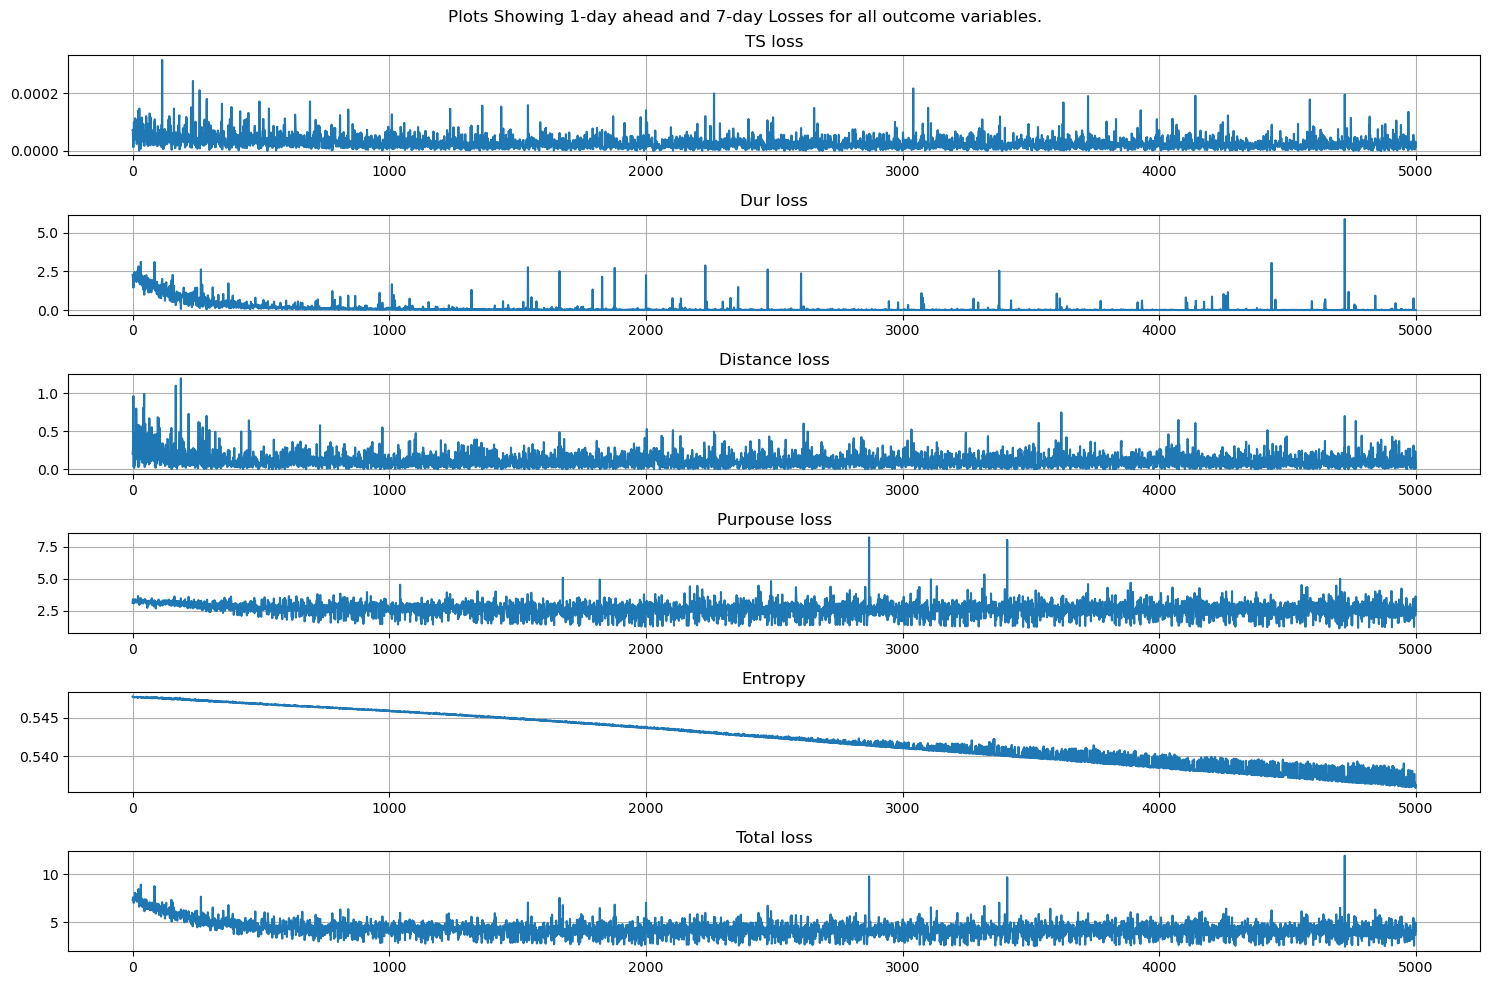

In [35]:
# Configure basic logging
logging.basicConfig(level=logging.INFO, force=True, format='%(levelname)s: %(message)s')


rnn_model = RNNmodel().to(device)

ce_loss = nn.CrossEntropyLoss(weight=ce_weighting, ignore_index=0).to(device)  #(y_hat, y)
mse_loss = nn.MSELoss(reduction="none").to(device)
bce_loss = nn.BCEWithLogitsLoss().to(device)

optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.0005)

epochs = 1
seq_length = 7
i_to_loop = 5000

c1_penalty_weight = 0.05
c2_penalty_weight = 0.2



ts_loss_weight = 1/800
dur_loss_weight = 10
purpouse_loss_weight = 1
distance_loss_weight = 50
istrip_loss_weight = 1

entropy_weight = 2
temperature = 5
tau = 2

make_travel_diaries = True
complete_travel_diaries = {}
complete_travel_diaries_dfs = []

total_losses = []
ts_losses= []
dur_losses= []
distance_losses = []
purpouse_losses = []
istrip_losses = []
entropy_evol = []


for epochi in range(epochs):

    for individual_i in range(i_to_loop):

        # Setting up prediction matrices for individual's travel week
        prediction_matrix_ts = []
        prediction_matrix_dur = []
        prediction_matrix_distance = []
        prediction_matrix_purpouse = []
        prediction_matrix_istrip = []

        masks = []

        entropies = []

        # Truth values for that individual
        true_matrix_ts = y_ts[individual_i, :, 0, :].to(torch.float32)
        true_matrix_dur = y_duration[individual_i, :, 0, :].to(torch.float32)
        true_matrix_distance = y_distance[individual_i, :, 0, :].to(torch.float32)
        true_matrix_purpouse = y_purpouse[individual_i, :, 0, :].reshape(7*max_journey_seq).to(torch.long)
        true_matrix_istrip = y_istrip[individual_i, :, 0, :].to(torch.float32)

        logging.debug(f"Matrices of true values shape,ts_te, distance, purpouse, istrip")
        logging.debug(f"{true_matrix_ts.shape}")
        logging.debug(f"{true_matrix_dur.shape}")
        logging.debug(f"{true_matrix_distance.shape}")
        logging.debug(f"{true_matrix_purpouse.shape}")
        logging.debug(f"{true_matrix_istrip.shape}")

        travel_diary = X[individual_i, :, 0, :].unsqueeze(1).to(torch.float32)
        logging.debug(travel_diary.shape)

        # 7-day mask containing just the time-independent features
        X_features = X[individual_i, :, 0, 5*max_journey_seq:].unsqueeze(1).to(torch.float32)   # Features with masking and after masking
        ts_feature = torch.zeros(7,1,max_journey_seq).to(torch.float32).to(device)
        dur_feature = torch.zeros(7,1,max_journey_seq).to(torch.float32).to(device)
        distance_feature = torch.zeros(7,1,max_journey_seq).to(torch.float32).to(device)
        purpouse_feature = torch.zeros(7,1,max_journey_seq*24).to(torch.float32).to(device)
        istrip_feature = torch.zeros(7,1,max_journey_seq).to(torch.float32).to(device)
        
        # Input matrix to feed into the model
        input_matrix = torch.concat([ts_feature, dur_feature, distance_feature, purpouse_feature, istrip_feature, X_features[:7,:,:]], dim=2)

        logging.debug(f"Shape of input matrix: {input_matrix.shape}")

        for t in range(0, seq_length):

            # Conditions of violation
    
            y_ts_pred_7, y_dur_pred_7, y_distance_pred_7, y_purpouse_pred_7, y_istrip_pred_7, is_trip_mask = rnn_model.forward(input_matrix)
            categorical_prediction7 = torch.argmax(y_purpouse_pred_7, dim=-1)

            # Reshaping
            y_purpouse_pred_7 = y_purpouse_pred_7.reshape(1,1,max_journey_seq*NUM_CLASSES)

            # Apply temperature-scaled softmax
            y_purpouse_softmax = F.softmax(y_purpouse_pred_7 / temperature, dim=-1)

            # Reshape back to match your input matrix (flattened)
            y_purpouse_softmax = y_purpouse_softmax.reshape(1, 1, max_journey_seq*NUM_CLASSES)

            # Trying with the gumbel
            #y_purpouse_gumbel = F.gumbel_softmax(y_purpouse_pred_7, tau=tau, hard=True).reshape(1, 1, 240)

            # Calculating entropy across trip
            entropy_t = -(y_purpouse_softmax.reshape(max_journey_seq,NUM_CLASSES) * torch.log(y_purpouse_softmax + 1e-8).reshape(max_journey_seq,NUM_CLASSES)).sum(dim=1)
            entropies.append(entropy_t)

            if individual_i > i_to_loop-5:
                logging.info(y_purpouse_softmax.reshape(max_journey_seq,NUM_CLASSES))

            y_istrip_pred_7 = y_istrip_pred_7.reshape(1,1,-1)


            #logging.debug("Predictions for {t}. Same order as always")
            #logging.debug(y_ts_pred_7.shape)
            #logging.debug(y_dur_pred_7.shape)
            #logging.debug(y_distance_pred_7.shape)
            #logging.debug(y_purpouse_pred_7.shape)
            #logging.debug(y_istrip_pred_7.shape)
            ##logging.debug(y_mask_7.shape)
            #logging.debug(f"Shape of this days X_features: {X_features[seq_length+t,:,:].unsqueeze(1).shape}")

            # New input row

            new_input_row = torch.concat([y_ts_pred_7, 
                                          y_dur_pred_7,
                                          y_distance_pred_7, 
                                          y_purpouse_softmax, 
                                          y_istrip_pred_7,
                                          X_features[seq_length+t,:,:].unsqueeze(1)], dim=2)

            # Appeding to input matrix

            # Slice off the first row of input_matrix

            input_matrix = input_matrix[1:,:,:]

            logging.debug(f"sliced of bottom row of input matrix, shape: {input_matrix.shape}")

            # Concatenate the redictions for t

            input_matrix = torch.cat([new_input_row, input_matrix], dim=0)

            logging.debug(f"New input matrix is input for next day: {input_matrix.shape}")

            logging.debug(input_matrix)

            # Appending to final prediction matrix
            prediction_matrix_ts.append(y_ts_pred_7.reshape(1,-1))
            prediction_matrix_dur.append(y_dur_pred_7.reshape(1,-1))            
            prediction_matrix_distance.append(y_distance_pred_7.reshape(1,-1))
            prediction_matrix_purpouse.append(y_purpouse_pred_7.reshape(max_journey_seq,NUM_CLASSES))
            prediction_matrix_istrip.append(y_istrip_pred_7.reshape(1,-1))

            # Old mask code

            #masks_ts_te.append(is_trip_mask.repeat_interleave(2).view(1,-1))
            masks.append(is_trip_mask.T)
        
            # Compute MSE and CE loss for one-day-ahead of the week

            #logging.debug(f"Original mask: {y_mask_7}")
            #logging.debug(f"interleaved_mask: {y_mask_7.repeat_interleave(2)}")


            # Compute MSE and CE loss for one-day-ahead of the week

        # Concatenating matrices

        # Making matrices of masks OLD CODE
        #masks_ts_te = torch.cat(masks_ts_te, 0)
        masks = torch.cat(masks, 0)

        purpouse_mask = torch.clamp(true_matrix_purpouse.reshape(7,max_journey_seq),max=1)

        #purpouse_mask_ts_te = purpouse_mask.repeat_interleave(2, dim=1)

        prediction_matrix_ts = torch.cat(prediction_matrix_ts, 0)
        prediction_matrix_dur = torch.cat(prediction_matrix_dur, 0)
        prediction_matrix_distance = torch.cat(prediction_matrix_distance, 0)
        prediction_matrix_purpouse = torch.cat(prediction_matrix_purpouse, 0) 
        prediction_matrix_istrip = torch.cat(prediction_matrix_istrip, 0)

        if make_travel_diaries:
            purpouse_for_show = torch.argmax(prediction_matrix_purpouse, dim=1).reshape(7,max_journey_seq)

            matrix_for_show = torch.cat([prediction_matrix_ts * masks, 
                                         prediction_matrix_dur * masks, 
                                         prediction_matrix_distance * masks, 
                                         purpouse_for_show * masks, 
                                         masks], dim=1)
            
            complete_travel_diaries[individual_i] = matrix_for_show

            df = pd.DataFrame(complete_travel_diaries[individual_i].cpu().detach().numpy())
            df.iloc[:,:2*max_journey_seq] = df.iloc[:,:2*max_journey_seq].apply(lambda x: custom_numerical_scaler(x=x, x_min=0, x_max=60*24, inverse=True))
            df.iloc[:,2*max_journey_seq:3*max_journey_seq] = df.iloc[:,2*max_journey_seq:3*max_journey_seq].apply(lambda x: log_transformer(x, inverse=True))
            df["i_id"] = individual_i

            complete_travel_diaries_dfs.append(df)

        # Calculating loss with masks applied
        logging.debug(f"Matrices prediction/ true in usual order prior to adding to losses")

        logging.debug(f"Prediction of TS")
        logging.debug(prediction_matrix_ts*purpouse_mask)
        logging.debug("")
        logging.debug(true_matrix_ts)

        ts_loss = mse_loss(prediction_matrix_ts,  true_matrix_ts)
        ts_loss = (ts_loss*purpouse_mask).sum() / (purpouse_mask.sum() + 1e-6)

        logging.debug(f"Prediction of DUR")
        logging.debug(prediction_matrix_dur*purpouse_mask)
        logging.debug("")
        logging.debug(true_matrix_dur)

        dur_loss = mse_loss(prediction_matrix_dur,  true_matrix_dur)
        dur_loss = (dur_loss*purpouse_mask).sum() / (purpouse_mask.sum() + 1e-6)

        logging.debug(f"Prediction of Distance")
        logging.debug(prediction_matrix_distance*purpouse_mask)
        logging.debug("")
        logging.debug(true_matrix_distance)

        distance_loss = mse_loss(torch.log(1+prediction_matrix_distance),  torch.log(1+true_matrix_distance) )
        distance_loss = (distance_loss*purpouse_mask).sum() / (purpouse_mask.sum() + 1e-6)

        logging.debug(f"Prediction of Purpouse")
        logging.debug(purpouse_for_show)
        logging.debug("")
        logging.debug(true_matrix_purpouse)

        purpouse_loss = ce_loss(prediction_matrix_purpouse, true_matrix_purpouse)

        logging.debug(f"Prediction of Is trip")
        logging.debug(prediction_matrix_istrip)
        logging.debug("")
        logging.debug(true_matrix_istrip)

        istrip_loss = bce_loss(prediction_matrix_istrip, true_matrix_istrip)

        # RATIONALITY CONDITIONS

        #ts_te_penalty_above_1 = torch.clamp(prediction_matrix_ts_te-1.0, min = 0).sum()

        # Encouraging entropy
        purpouse_entropy = torch.stack(entropies, dim=0).mean()

        #  c2_penalty_weight*ts_te_penalty_above_1

        total_loss = ts_loss*ts_loss_weight + dur_loss*dur_loss_weight + distance_loss + purpouse_loss*purpouse_loss_weight + istrip_loss  + entropy_weight*purpouse_entropy

        logging.debug(f"ts_te Loss requires grad? {ts_loss.requires_grad}")
        logging.debug(f"Distance Loss requires grad? {distance_loss.requires_grad}")
        logging.debug(f"Purpouse Loss requires grad? {purpouse_loss.requires_grad}")
        logging.debug(f"is trip Loss requires grad? {istrip_loss.requires_grad}")

        logging.info(f"epoch: {epochi} | individual: {individual_i+1}")
        #logging.info(f"ts_ts_loss: {ts_te_loss*ts_te_loss_weight:.2f}")
        #logging.info(f"distance_loss: {distance_loss:.2f}")
        #logging.info(f"purpouse_loss: {purpouse_loss:.2f}")
        #logging.info(f"istrip_loss: {istrip_loss:.2f}")
        logging.info(f"total_loss: {total_loss:.2f}")

        # Appending losses
        total_losses.append(total_loss.cpu().detach().numpy())
        ts_losses.append(  (ts_loss*ts_loss_weight).cpu().detach().numpy())
        dur_losses.append(  (dur_loss*dur_loss_weight).cpu().detach().numpy())
        distance_losses.append(distance_loss.cpu().detach().numpy())
        purpouse_losses.append((purpouse_loss*purpouse_loss_weight).cpu().detach().numpy())
        istrip_losses.append(istrip_loss.cpu().detach().numpy())
        entropy_evol.append(purpouse_entropy.cpu().detach().numpy())

        # BACKPROP
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()



plt.figure(figsize=(15, 10))

plt.suptitle("Plots Showing 1-day ahead and 7-day Losses for all outcome variables.")

x_vals = np.arange(i_to_loop)  # Ensure correct x-axis scaling




plt.subplot(6,1,1)
plt.title("TS loss")
plt.plot(x_vals, ts_losses, label="ts_te")
plt.grid()

plt.subplot(6,1,2)
plt.title("Dur loss")
plt.plot(x_vals, dur_losses, label="ts_te")
plt.grid()


plt.subplot(6,1,3)
plt.title("Distance loss")
plt.plot(x_vals, distance_losses, label="distance")
plt.grid()

plt.subplot(6,1,4)
plt.title("Purpouse loss")
plt.plot(x_vals, purpouse_losses, label="purpouse")
plt.grid()

plt.subplot(6,1,5)
plt.title("Entropy")
plt.plot(x_vals, entropy_evol, label="entropy")
plt.grid()


plt.subplot(6,1,6)
plt.title("Total loss")
plt.plot(x_vals, total_losses)

plt.grid()

plt.tight_layout()



plt.show()
        

In [95]:
full_df = pd.concat(complete_travel_diaries_dfs)

In [96]:
stub_cols = ["TripStart", "Duration", "Distance", "Purpouse", "IsTrip"]
target_cols = [f"{col}_{i}" for col in stub_cols for i in range(1, max_journey_seq+1)]

target_cols+= ["i_id"]

In [97]:
target_cols

['TripStart_1',
 'TripStart_2',
 'TripStart_3',
 'TripStart_4',
 'TripStart_5',
 'TripStart_6',
 'TripStart_7',
 'TripStart_8',
 'TripStart_9',
 'TripStart_10',
 'Duration_1',
 'Duration_2',
 'Duration_3',
 'Duration_4',
 'Duration_5',
 'Duration_6',
 'Duration_7',
 'Duration_8',
 'Duration_9',
 'Duration_10',
 'Distance_1',
 'Distance_2',
 'Distance_3',
 'Distance_4',
 'Distance_5',
 'Distance_6',
 'Distance_7',
 'Distance_8',
 'Distance_9',
 'Distance_10',
 'Purpouse_1',
 'Purpouse_2',
 'Purpouse_3',
 'Purpouse_4',
 'Purpouse_5',
 'Purpouse_6',
 'Purpouse_7',
 'Purpouse_8',
 'Purpouse_9',
 'Purpouse_10',
 'IsTrip_1',
 'IsTrip_2',
 'IsTrip_3',
 'IsTrip_4',
 'IsTrip_5',
 'IsTrip_6',
 'IsTrip_7',
 'IsTrip_8',
 'IsTrip_9',
 'IsTrip_10',
 'i_id']

In [98]:
full_df.columns = target_cols


In [99]:
full_df = full_df.reset_index()

In [110]:
full_df = full_df.rename(columns={"index": "DoW"})

In [115]:
long_full_df = pd.wide_to_long(full_df, stubnames=stub_cols, i=["i_id", "DoW"], sep="_", j="TripNum").reset_index()

In [118]:
long_full_df

,i_id,DoW,TripNum,TripStart,Duration,Distance,Purpouse,IsTrip
0,0,0,1,535.507080,702.441101,0.995372,23.0,1.0
1,0,0,2,666.727356,658.334229,1.802345,22.0,1.0
2,0,0,3,0.000000,0.000000,0.000000,0.0,0.0
3,0,0,4,0.000000,0.000000,0.000000,0.0,0.0
4,0,0,5,698.712036,892.831177,1.448078,0.0,1.0
...,...,...,...,...,...,...,...,...
349995,4999,6,6,0.000000,0.000000,0.000000,0.0,0.0
349996,4999,6,7,0.000000,0.000000,0.000000,0.0,0.0
349997,4999,6,8,0.000000,0.000000,0.000000,0.0,0.0
349998,4999,6,9,0.000000,0.000000,0.000000,0.0,0.0


In [125]:
long_full_df = long_full_df[long_full_df["Purpouse"] != 0]

In [144]:
long_full_df

,i_id,DoW,TripNum,TripStart,Duration,Distance,Purpouse,IsTrip
0,0,0,1,535.507080,702.441101,0.995372,23.0,1.0
1,0,0,2,666.727356,658.334229,1.802345,22.0,1.0
5,0,0,6,819.607483,796.765076,1.124416,11.0,1.0
6,0,0,7,982.576050,723.890442,1.366893,18.0,1.0
9,0,0,10,686.124512,732.381104,1.040945,14.0,1.0
...,...,...,...,...,...,...,...,...
349973,4999,4,4,961.032837,36.373211,3.791709,10.0,1.0
349976,4999,4,7,1015.747925,55.429337,3.284159,23.0,1.0
349980,4999,5,1,551.955750,21.213707,5.511454,1.0,1.0
349986,4999,5,7,1015.747925,55.429337,3.284159,23.0,1.0


In [161]:
long_full_df.loc[70000:,:].groupby("Purpouse").median()

,i_id,DoW,TripNum,TripStart,Duration,Distance,IsTrip
Purpouse,,,,,,,
1.0,2881.0,3.0,1.0,674.751953,49.818741,4.581140,1.0
5.0,3042.5,3.0,3.0,896.257751,55.222710,3.655875,1.0
6.0,3945.0,3.0,3.0,863.812256,57.454342,2.712049,1.0
10.0,2535.0,3.0,4.0,965.654907,74.686333,3.360578,1.0
11.0,1253.0,3.0,9.0,662.632263,651.235107,1.405144,1.0
21.0,3951.0,4.0,10.0,1023.292786,221.064835,1.845116,1.0
23.0,3149.0,3.0,6.0,1028.701660,82.823257,2.925476,1.0


In [ ]:
ts_df2017["Tr"]

In [159]:
ts_df2017.groupby("TripPurpose_B01ID")[["TripStart", "TripEnd", "TripDisExSW"]].median()

,TripStart,TripEnd,TripDisExSW
TripPurpose_B01ID,,,
1.0,755.0,775.0,7.0
2.0,750.0,777.0,8.0
3.0,515.0,535.5,5.0
4.0,750.0,775.0,7.5
5.0,780.0,795.0,2.0
6.0,773.0,790.0,3.5
7.0,710.0,725.0,3.0
8.0,845.0,876.5,4.0
9.0,760.0,780.0,3.0


In [149]:
ts_df2017["TripPurpose_B01ID"].value_counts(normalize=True)

TripPurpose_B01ID
1.0     0.201634
5.0     0.106069
6.0     0.096783
10.0    0.095383
21.0    0.066298
9.0     0.063832
23.0    0.063791
13.0    0.062746
2.0     0.048356
16.0    0.039365
22.0    0.029430
11.0    0.025878
7.0     0.021666
19.0    0.020357
3.0     0.017252
14.0    0.014918
12.0    0.010909
15.0    0.008738
4.0     0.003481
20.0    0.002527
8.0     0.000426
18.0    0.000162
Name: proportion, dtype: float64

In [147]:
long_full_df.loc[60000:,"Purpouse"].value_counts(normalize=True)

Purpouse
1.0     0.557574
10.0    0.208212
5.0     0.117203
23.0    0.086000
6.0     0.028057
11.0    0.002648
21.0    0.000305
Name: proportion, dtype: float64

In [42]:
full_df.to_csv("/home/trapfishscott/Cambridge24.25/D200_ML_econ/ProblemSets/Project/data/complete_trav_diaries.csv", index=False)

In [48]:
full_df

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,i_id
0,535.507080,666.727356,0.000000,0.000000,698.712036,819.607483,982.576050,0.000000,0.000000,686.124512,...,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0
1,535.818604,666.230957,0.000000,754.077637,0.000000,0.000000,981.460815,0.000000,608.957214,684.340332,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0
2,535.876587,666.071655,0.000000,0.000000,0.000000,0.000000,0.000000,675.943298,608.891357,683.862854,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0
3,0.000000,666.023376,558.542114,0.000000,0.000000,820.847351,0.000000,0.000000,608.745117,0.000000,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
4,0.000000,666.145508,558.699951,0.000000,699.095276,821.063904,0.000000,675.511902,0.000000,0.000000,...,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,0.000000,892.735046,900.106873,961.032837,0.000000,0.000000,1015.747925,0.000000,0.000000,0.000000,...,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4999
3,551.955750,892.735046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4999
4,0.000000,0.000000,0.000000,961.032837,0.000000,0.000000,1015.747925,0.000000,0.000000,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4999
5,551.955750,0.000000,0.000000,0.000000,0.000000,0.000000,1015.747925,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4999


In [ ]:
### INDIVIDUAL PARTS ####

# RATIONALITY CONDITIONS

ts_te_penalty_above_11 = torch.clamp(y_ts_te_pred_1-1, min = 0).sum()
ts_te_penalty_above_17 = torch.clamp(y_ts_te_pred_7-1, min = 0).sum()

ts_te_delta1 = y_ts_te_pred_1[:,:,1::2] - y_ts_te_pred_1[:,:,0::2]
ts_te_delta7 = y_ts_te_pred_7[:,:,1::2] - y_ts_te_pred_7[:,:,0::2]

max_distance1 = ts_te_delta1 * normalised_mp_minute
max_distance7 = ts_te_delta7 * normalised_mp_minute

max_distance_penalty1 = torch.clamp(y_distance_pred_1 - max_distance1, min=0).sum()
min_distance_penalty1 = torch.clamp(-y_distance_pred_1, min=0).sum()
total_distance_penalty1 = max_distance_penalty1 + max_distance_penalty1

max_distance_penalty7 = torch.clamp(y_distance_pred_7 - max_distance7, min=0).sum()
min_distance_penalty7 = torch.clamp(-y_distance_pred_7, min=0).sum()
total_distance_penalty7 = max_distance_penalty7 + max_distance_penalty7